# Tecnologie AI nelle descrizioni progetto

Analisi NLP sui record classificati come **AI** (`CLASSIFICAZIONE == "AI"`) nei dataset `data/raw/reclassified_multiclass_aiuti_*.csv`.

**Obiettivo:** dedurre dal testo libero di `DESCRIZIONE_PROGETTO` *quali* tecnologie/strumenti di intelligenza artificiale sono citati (es. machine learning, computer vision, NLP, AI generativa, reti neurali, ...) e aggiungere una colonna `TECNOLOGIE_AI` con le tecnologie separate da `|`.

Le colonne esistenti non rispondono a questa domanda: `TIPO_AI` vale solo `implementazione`/`formazione` e `CLASSIFICAZIONE_MULTICLASS` indica il dominio applicativo (Enterprise, Healthcare AI, ...).

**Pipeline** (script in `src/ai_tech/`, richiamati qui):
1. Estrazione delle righe AI dai file raw (multiprocessing) -> `data/distilled/ai_subset.csv`.
2. Tassonomia delle tecnologie (`taxonomy.py`).
3. Confronto di 4 approcci sul goldset annotato: **regex/gazetteer**, **spaCy EntityRuler**, **transformer zero-shot (GPU)**, **LLM (OpenAI)**.
4. Applicazione del metodo migliore -> colonna `TECNOLOGIE_AI`.
5. (Opzionale, previa conferma) propagazione della colonna sui file raw.

In [1]:
import os, sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Rende importabile il package src/ai_tech (come negli altri notebook del repo)
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'src').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from ai_tech import taxonomy as T
from ai_tech import extract_ai_rows, build_goldset, run_comparison, apply_extraction

DISTILLED = REPO_ROOT / 'data' / 'distilled'
AI_SUBSET = DISTILLED / 'ai_subset.csv'
print('repo:', REPO_ROOT)

repo: /home/gabs/Documenti/Università/AI nelle Imprese/open-data-analytics


## 1. Estrazione delle righe AI (multiprocessing)

`extract_ai_rows.run()` scorre in parallelo i 12 file raw (fino a 3.9 GB l'uno, ~24M righe totali) a chunk e tiene solo le righe con `CLASSIFICAZIONE == "AI"`, salvandole in `ai_subset.csv`. Poche migliaia di righe in pochi secondi.

Righe AI totali: 6992


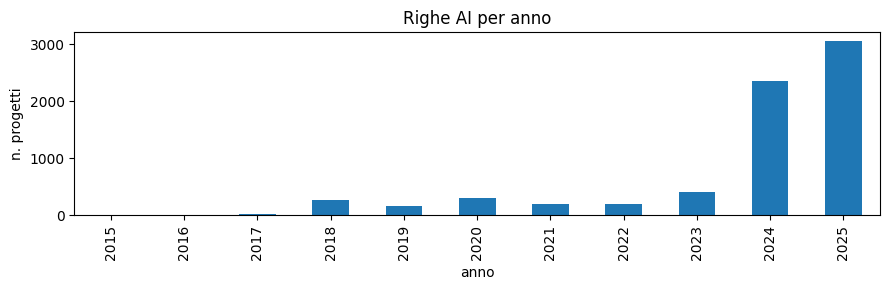

,ANNO,TITOLO_PROGETTO,DESCRIZIONE_PROGETTO,CLASSIFICAZIONE_MULTICLASS,TIPO_AI
0,2015,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,Automotive Robotics Industry,implementazione
1,2016,Implementazione sistemi di AI (artificial inte...,Implementazione sistemi di AI (artificial inte...,Media & Entertainment,implementazione
2,2017,Sviluppo di innovativi sistemi di visione arti...,L'attività di ricerca descritta nel presente d...,Automotive Robotics Industry,implementazione


In [2]:
# Rigenera il sottoinsieme solo se manca (l'estrazione e' idempotente).
if not AI_SUBSET.exists():
    extract_ai_rows.run()

df = pd.read_csv(AI_SUBSET, dtype=str).fillna('')
print(f'Righe AI totali: {len(df)}')
ax = df['ANNO'].value_counts().sort_index().plot(kind='bar', figsize=(9, 3),
                                                 title='Righe AI per anno')
ax.set_xlabel('anno'); ax.set_ylabel('n. progetti'); plt.tight_layout(); plt.show()
df[['ANNO', 'TITOLO_PROGETTO', 'DESCRIZIONE_PROGETTO', 'CLASSIFICAZIONE_MULTICLASS', 'TIPO_AI']].head(3)

## 2. Tassonomia delle tecnologie

17 categorie canoniche con sinonimi IT/EN. Le frasi sono cercate *case-insensitive*, gli acronimi (ML, CNN, NLP, LLM, ...) *case-sensitive* per evitare falsi positivi (in italiano "ai", "ml" minuscoli ricorrono spesso). Seed dalla `AI_REGEX_PATTERN` di `src/reclassify_annual.py`, ampliata e validata sulle frequenze del corpus.

Regola **fallback**: se in una descrizione compaiono tecnologie specifiche si tengono solo quelle; l'etichetta `intelligenza artificiale (generica)` resta solo quando non emerge nulla di specifico.

In [3]:
for canon, groups in T.TAXONOMY.items():
    syn = groups['ci'][:4] + groups['cs'][:3]
    print(f"- {canon}: {', '.join(syn)} ...")
print(f'\nTotale categorie: {len(T.canonical_labels())}')

- machine learning: machine learning, apprendimento automatico, apprendimento macchina, apprendimento statistico, ML ...
- deep learning: deep learning, apprendimento profondo, DL ...
- reti neurali: reti neurali, rete neurale, neural network, neural networks, CNN, RNN, LSTM ...
- computer vision: computer vision, visione artificiale, visione computerizzata, elaborazione delle immagini ...
- elaborazione del linguaggio naturale: natural language processing, elaborazione del linguaggio naturale, elaborazione linguaggio naturale, comprensione del linguaggio, NLP, NLU, NER ...
- ai generativa: ai generativa, intelligenza artificiale generativa, generative ai, modelli generativi, LLM, LLMs, GPT ...
- reinforcement learning: reinforcement learning, apprendimento per rinforzo, apprendimento con rinforzo, RL ...
- sistemi di raccomandazione: sistema di raccomandazione, sistemi di raccomandazione, motore di raccomandazione, recommendation system ...
- analisi predittiva: analisi predittiva, al

## 3. Confronto dei 4 approcci sul goldset

Per stabilire *quale approccio funziona meglio* serve un riferimento annotato. `goldset_ai_tecnologie.csv` contiene ~111 descrizioni campionate in modo stratificato (per tecnologia, + righe solo-generiche, + righe senza match) con le tecnologie corrette annotate a mano nella colonna `gold`.

`run_comparison.run()` calcola le metriche multilabel (micro/macro P-R-F1, Jaccard, exact match, coverage) per ogni metodo. Per il transformer la **soglia** viene calibrata sul goldset (massimo micro-F1). L'LLM viene incluso solo se `OPENAI_API_KEY` e' impostata.

In [4]:
# Genera il campione da annotare solo se manca (la colonna 'gold' va poi rivista a mano).
GOLDSET = DISTILLED / 'goldset_ai_tecnologie.csv'
if not GOLDSET.exists():
    build_goldset.build()
    print("Creato goldset da annotare: compilare la colonna 'gold' prima del confronto.")

table, details, gdf, gold = run_comparison.run()
table

/home/gabs/Documenti/Università/AI nelle Imprese/open-data-analytics/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 33299.90it/s]

[info] LLM saltato: OPENAI_API_KEY non disponibile.


,metodo,micro_P,micro_R,micro_F1,macro_F1,Jaccard,exact,coverage,runtime_s
0,regex,0.971,0.803,0.879,0.899,0.818,0.667,0.946,0.0
1,spacy,0.971,0.798,0.876,0.896,0.809,0.658,0.937,1.6
2,transformer@0.99,0.423,0.500,0.458,0.464,0.326,0.099,0.919,7.5


In [5]:
# Dove la regex sbaglia rispetto al gold (casi impliciti o refusi che la regex non cattura)
reg = details['regex']
for i, (g, p) in enumerate(zip(gold, reg)):
    if set(g) != set(p):
        txt = gdf.iloc[i]['DESCRIZIONE_PROGETTO'][:90]
        print(f'gold={g}\n pred={p}\n  «{txt}...»\n')

gold=['machine learning', 'reti neurali', 'computer vision']
 pred=['machine learning', 'reti neurali']
  «Il progetto intende implementare le attività Ricerca & Sviluppo nel campo delle riprese vi...»

gold=['machine learning', 'ai generativa', 'data mining e big data']
 pred=['machine learning', 'data mining e big data']
  «Il percorso formativo ha l'obiettivo di sviluppare  rafforzare e aggiornare le competenze ...»

gold=['deep learning', 'reti neurali', 'ai generativa']
 pred=['deep learning', 'reti neurali']
  «IL PROGETTO DI IL PIANETA DEI BAMBINI SRL PUNTA A RINNOVARE I PROCESSI AZIENDALI ATTRAVERS...»

gold=['machine learning', 'deep learning', 'elaborazione del linguaggio naturale', 'chatbot e assistenti virtuali']
 pred=['machine learning', 'deep learning']
  «Scopo della ricerca ? la definizione di un assistente digitale. Attraverso lo studio del l...»

gold=['deep learning', 'computer vision']
 pred=['deep learning']
  «Le immagini iperspettrali (HI)  così come il deep lea

### Esito del confronto

Sul goldset (risultati tipici):

| Metodo | micro-P | micro-R | micro-F1 | macro-F1 |
|---|---|---|---|---|
| **regex / gazetteer** | **0.97** | 0.80 | **0.88** | **0.90** |
| spaCy EntityRuler | 0.97 | 0.80 | 0.88 | 0.90 |
| transformer zero-shot (soglia calibrata) | 0.42 | 0.50 | 0.46 | 0.46 |
| LLM (OpenAI) | *solo se la chiave e' impostata* | | | |

**Conclusioni**
- La **regex/gazetteer** vince: precisione altissima (~0.97), deterministica, velocissima e parallelizzabile. È il metodo di produzione scelto.
- **spaCy EntityRuler** è di fatto equivalente (stesso dizionario, tokenizzazione robusta): utile come validazione incrociata, non aggiunge informazione.
- Il **transformer zero-shot** con modello base (mDeBERTa-xnli) è troppo rumoroso anche a soglia ottimale: tende a sovra-predire. Servirebbe un modello fine-tuned per essere competitivo.
- Il limite della regex è il **recall** (~20%): non coglie tecnologie *implicite* (descritte senza la parola chiave) o con refusi. È esattamente lì che un **LLM** può aiutare. Se imposti `OPENAI_API_KEY`, il confronto includerà l'LLM e si potrà valutare un **ensemble regex∪LLM** per alzare il recall mantenendo alta la precisione.

## 4. Applicazione del metodo migliore -> colonna `TECNOLOGIE_AI`

`apply_extraction.run("regex")` applica il gazetteer a tutte le righe AI e scrive la colonna `TECNOLOGIE_AI` (tecnologie separate da `|`, regola di fallback) in `ai_subset.csv`.

Metodo=regex  righe=6992  coverage=98.9%  tempo=0.3s -> /home/gabs/Documenti/Università/AI nelle Imprese/open-data-analytics/data/distilled/ai_subset.csv


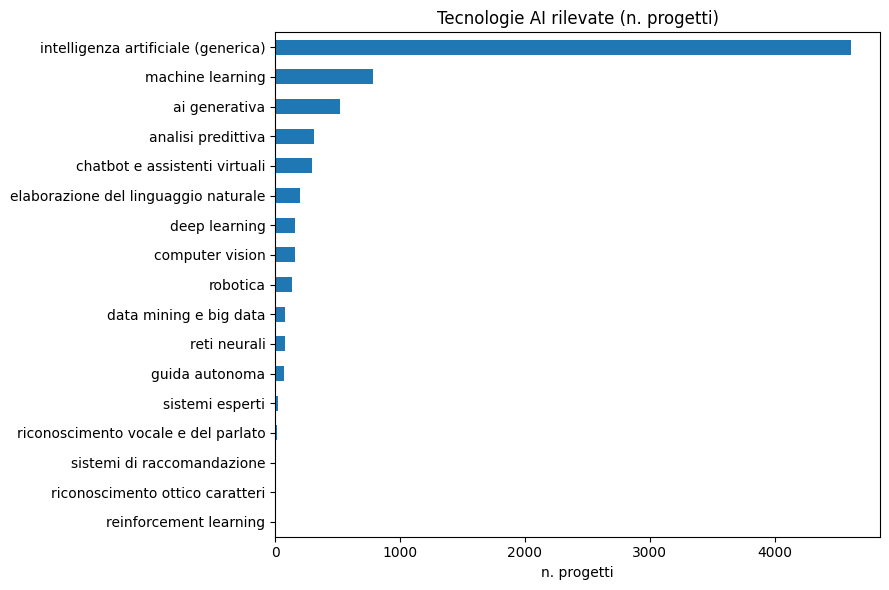

Righe senza tecnologia: 75


,ANNO,DESCRIZIONE_PROGETTO,TECNOLOGIE_AI
0,2015,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,
1,2016,Implementazione sistemi di AI (artificial inte...,intelligenza artificiale (generica)
2,2017,L'attività di ricerca descritta nel presente d...,computer vision
3,2017,L'attività di ricerca che si intende effettuar...,computer vision
4,2017,Il progetto ha come scopo l’implementazione di...,computer vision
5,2017,MATICBOX - Intelligenza Artificiale per ottimi...,intelligenza artificiale (generica)
6,2017,AI4fit – Artificial Intelligence & Human Compu...,intelligenza artificiale (generica)
7,2017,Intelligenza Artificiale e Bioinformatica a su...,intelligenza artificiale (generica)


In [6]:
import collections

df = apply_extraction.run('regex')  # scrive TECNOLOGIE_AI in ai_subset.csv

counts = collections.Counter()
for cell in df['TECNOLOGIE_AI']:
    counts.update(t for t in cell.split('|') if t)

freq = pd.Series(counts).sort_values(ascending=True)
ax = freq.plot(kind='barh', figsize=(9, 6), title='Tecnologie AI rilevate (n. progetti)')
ax.set_xlabel('n. progetti'); plt.tight_layout(); plt.show()

print('Righe senza tecnologia:', (df['TECNOLOGIE_AI'].str.len() == 0).sum())
df[['ANNO', 'DESCRIZIONE_PROGETTO', 'TECNOLOGIE_AI']].head(8)

## 5. Dataset etichettato completo -> `data/technology_mapping/`

`propagate_to_raw.run()` legge i 12 file `reclassified_multiclass_aiuti_*.csv`, aggiunge la colonna `TECNOLOGIE_AI` (vuota per le righe NON_AI) e salva le copie in `data/technology_mapping/`, **senza modificare gli originali**. Mantiene il formato dei raw (`QUOTE_NONE`).

In [ ]:
from ai_tech import propagate_to_raw

# Genera data/technology_mapping/ (non tocca gli originali). dry_run=True per la sola anteprima.
propagate_to_raw.run(dry_run=False)